In [1]:
pip install requests pandas sqlalchemy


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import pandas as pd

# Запрос к Open-Meteo API - температура в Кёльне за последние 7 дней
url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 50.938,
    "longitude": 6.960,
    "hourly": "temperature_2m,wind_speed_10m",
    "past_days": 7,
    "forecast_days": 1,
    "timezone": "Europe/Berlin"
}

response = requests.get(url, params=params)
data = response.json()

print("Статус:", response.status_code)
print("Ключи в ответе:", list(data.keys()))

Статус: 200
Ключи в ответе: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly']


In [3]:
# Извлекаем нужные данные и делаем DataFrame
df = pd.DataFrame({
    "timestamp": data["hourly"]["time"],
    "temperature_c": data["hourly"]["temperature_2m"],
    "wind_speed_kmh": data["hourly"]["wind_speed_10m"]
})

# Превращаем строку времени в настоящий datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Смотрим что получилось
print(df.shape)
df.head(10)

(192, 3)


,timestamp,temperature_c,wind_speed_kmh
0,2026-02-24 00:00:00,10.2,14.0
1,2026-02-24 01:00:00,10.1,14.8
2,2026-02-24 02:00:00,10.2,14.4
3,2026-02-24 03:00:00,9.9,5.4
4,2026-02-24 04:00:00,9.8,5.4
5,2026-02-24 05:00:00,9.7,5.8
6,2026-02-24 06:00:00,9.6,6.5
7,2026-02-24 07:00:00,10.0,7.2
8,2026-02-24 08:00:00,9.7,7.6
9,2026-02-24 09:00:00,9.8,4.0


In [4]:
# Проверяем на пропущенные значения
print("Пропущенные значения:")
print(df.isnull().sum())

# Проверяем на дубликаты
print("\nДубликаты:", df.duplicated().sum())

# Добавляем полезные колонки
df["date"] = df["timestamp"].dt.date
df["hour"] = df["timestamp"].dt.hour

# Простая статистика
print("\nСтатистика:")
print(df[["temperature_c", "wind_speed_kmh"]].describe())

Пропущенные значения:
timestamp         0
temperature_c     0
wind_speed_kmh    0
dtype: int64

Дубликаты: 0

Статистика:
       temperature_c  wind_speed_kmh
count     192.000000      192.000000
mean       11.858854       10.325521
std         3.262307        4.113994
min         4.800000        0.700000
25%         9.700000        7.500000
50%        11.600000       10.100000
75%        14.000000       13.000000
max        19.400000       25.200000


In [5]:
from sqlalchemy import create_engine

# Создаём базу данных (файл появится в той же папке что и notebook)
engine = create_engine("sqlite:///weather_koeln.db")

# Загружаем DataFrame в таблицу
df.to_sql("weather", engine, if_exists="replace", index=False)

print("✅ Данные сохранены в базу!")

# Проверяем — читаем обратно из базы
df_check = pd.read_sql("SELECT * FROM weather LIMIT 5", engine)
print(df_check)

✅ Данные сохранены в базу!
                    timestamp  temperature_c  wind_speed_kmh        date  hour
0  2026-02-24 00:00:00.000000           10.2            14.0  2026-02-24     0
1  2026-02-24 01:00:00.000000           10.1            14.8  2026-02-24     1
2  2026-02-24 02:00:00.000000           10.2            14.4  2026-02-24     2
3  2026-02-24 03:00:00.000000            9.9             5.4  2026-02-24     3
4  2026-02-24 04:00:00.000000            9.8             5.4  2026-02-24     4


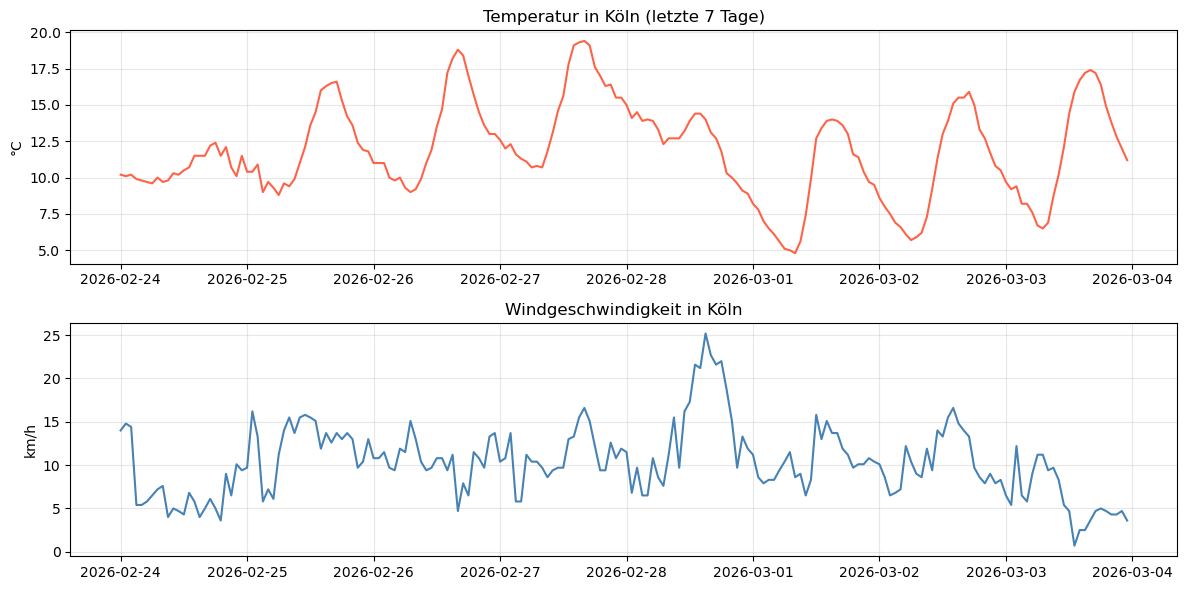

✅ График сохранён!


In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# Температура
ax1.plot(df["timestamp"], df["temperature_c"], color="tomato")
ax1.set_title("Temperatur in Köln (letzte 7 Tage)")
ax1.set_ylabel("°C")
ax1.grid(True, alpha=0.3)

# Ветер
ax2.plot(df["timestamp"], df["wind_speed_kmh"], color="steelblue")
ax2.set_title("Windgeschwindigkeit in Köln")
ax2.set_ylabel("km/h")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("weather_koeln.png")
plt.show()

print("✅ График сохранён!")

In [1]:
# test1

In [2]:
2+2

4